# Dubai Real Estate Price Predictor
## Notebook 1: Exploratory Data Analysis
**Data Source:** Dubai Land Department — Official Transactions Dataset  
**Author:** Vikas Varma Mudunuru  
**Goal:** Understand the data, clean it, and extract insights that drive feature engineering and modelling.

## 1. Setup & Data Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

# Load data
df = pd.read_csv('/content/transactions.csv')
print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')

Dataset shape: (1542814, 46)
Rows: 1,542,814 | Columns: 46


In [5]:
# Quick first look
df.head(3)

,transaction_id,procedure_id,trans_group_id,trans_group_ar,trans_group_en,procedure_name_ar,procedure_name_en,instance_date,property_type_id,property_type_ar,...,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3
0,3-9-2006-163,9,3,هبات,Gifts,هبه,Grant,16-10-2006,4,فيلا,...,NaN,0,3162.42,12000000.0,3794.56,NaN,NaN,3.0,1.0,0.0
1,3-9-2019-2944,9,3,هبات,Gifts,هبه,Grant,13-11-2019,1,أرض,...,NaN,0,209.09,916659.0,4384.04,NaN,NaN,2.0,4.0,0.0
2,2-13-2001-690,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,20-08-2001,2,مبنى,...,NaN,0,1337.80,4519342.0,3378.19,NaN,NaN,1.0,1.0,0.0


In [6]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1542814 entries, 0 to 1542813
Data columns (total 46 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   transaction_id        1542814 non-null  object 
 1   procedure_id          1542814 non-null  int64  
 2   trans_group_id        1542814 non-null  int64  
 3   trans_group_ar        1542814 non-null  object 
 4   trans_group_en        1542814 non-null  object 
 5   procedure_name_ar     1542814 non-null  object 
 6   procedure_name_en     1542814 non-null  object 
 7   instance_date         1542814 non-null  object 
 8   property_type_id      1542814 non-null  int64  
 9   property_type_ar      1542814 non-null  object 
 10  property_type_en      1542814 non-null  object 
 11  property_sub_type_id  1221795 non-null  float64
 12  property_sub_type_ar  1221795 non-null  object 
 13  property_sub_type_en  1221795 non-null  object 
 14  property_usage_ar     1542814 non-

## 2. Data Cleaning

In [7]:
# --- Step 1: Keep only Sales transactions ---
print(f'Transaction types:\n{df["trans_group_en"].value_counts()}\n')
df = df[df['trans_group_en'] == 'Sales'].copy()
print(f'After filtering to Sales only: {df.shape[0]:,} rows')

Transaction types:
trans_group_en
Sales        1176465
Mortgages     309215
Gifts          57134
Name: count, dtype: int64

After filtering to Sales only: 1,176,465 rows


In [8]:
# --- Step 2: Drop rows where price or area is missing or zero ---
df = df[df['actual_worth'] > 0]
df = df[df['procedure_area'] > 0]
print(f'After removing zero/null prices and areas: {df.shape[0]:,} rows')

After removing zero/null prices and areas: 1,176,465 rows


In [9]:
# --- Step 3: Remove extreme outliers (top and bottom 1%) ---
low = df['actual_worth'].quantile(0.01)
high = df['actual_worth'].quantile(0.99)
df = df[(df['actual_worth'] >= low) & (df['actual_worth'] <= high)]
print(f'After removing outliers (1%-99%): {df.shape[0]:,} rows')
print(f'Price range: AED {low:,.0f} — AED {high:,.0f}')

After removing outliers (1%-99%): 1,153,228 rows
Price range: AED 210,000 — AED 23,599,032


In [10]:
# --- Step 4: Parse dates ---
df['instance_date'] = pd.to_datetime(df['instance_date'], errors='coerce')
df['year'] = df['instance_date'].dt.year
df['month'] = df['instance_date'].dt.month
df['quarter'] = df['instance_date'].dt.quarter
print('Date columns created: year, month, quarter')

Date columns created: year, month, quarter


In [11]:
# --- Step 5: Create key engineered features ---
df['price_per_sqm'] = df['actual_worth'] / df['procedure_area']
df['is_offplan'] = (df['reg_type_en'].str.lower().str.contains('off', na=False)).astype(int)
df['has_parking'] = df['has_parking'].fillna('N').map({'Y': 1, 'N': 0})

print('New features created:')
print('  price_per_sqm — price per square metre (AED)')
print('  is_offplan    — 1 if off-plan, 0 if ready')
print('  has_parking   — 1 if parking included')

New features created:
  price_per_sqm — price per square metre (AED)
  is_offplan    — 1 if off-plan, 0 if ready
  has_parking   — 1 if parking included


In [12]:
# --- Null check after cleaning ---
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print('Columns with >5% nulls:')
print(null_pct[null_pct > 5])

Columns with >5% nulls:
has_parking             100.000000
rent_value              100.000000
meter_rent_price        100.000000
nearest_mall_en          30.832671
nearest_mall_ar          30.832671
nearest_metro_en         30.304328
nearest_metro_ar         30.304328
building_name_ar         23.624817
building_name_en         23.586229
project_name_en          22.095804
project_number           22.095804
project_name_ar          22.095804
nearest_landmark_en      20.082065
nearest_landmark_ar      20.082065
rooms_ar                 16.702942
rooms_en                 16.702942
property_sub_type_id     15.329406
property_sub_type_en     15.329406
property_sub_type_ar     15.329406
master_project_ar        12.482094
master_project_en        12.481920
dtype: float64


## 3. Target Variable Analysis — actual_worth

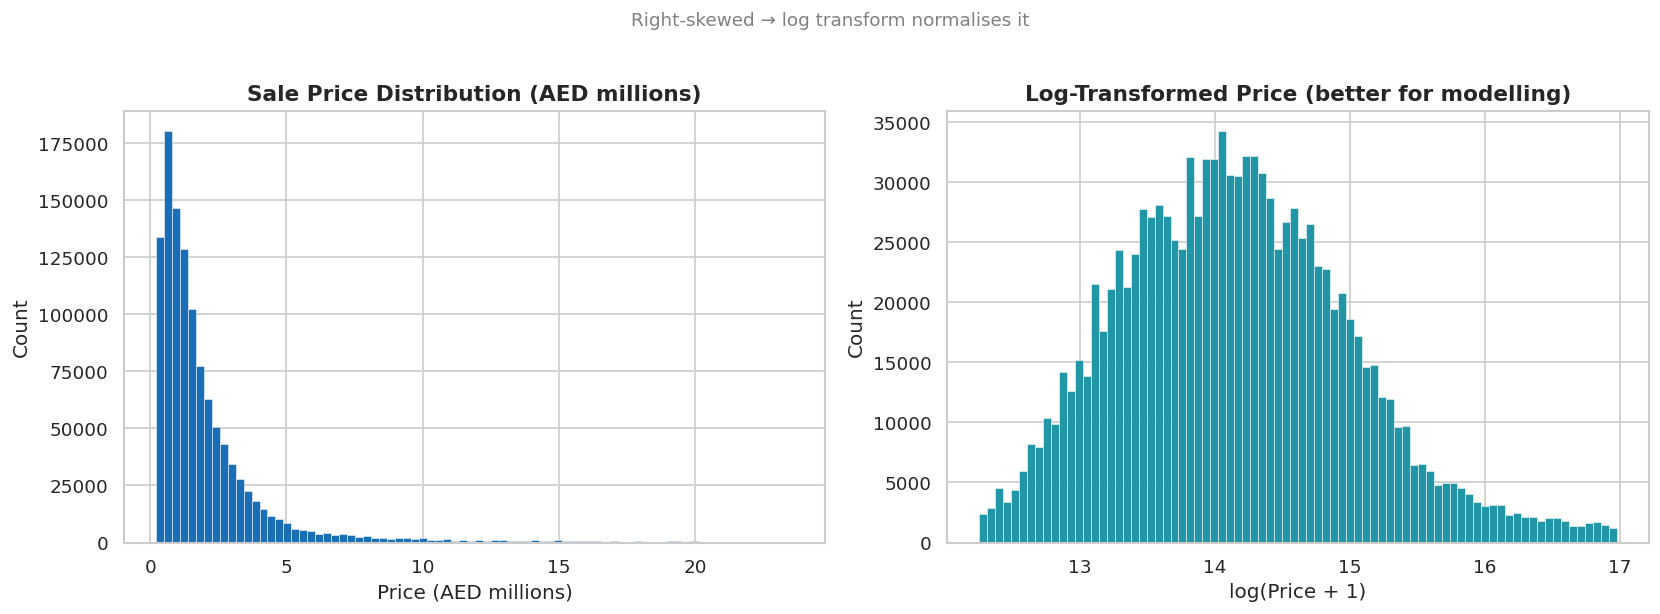

Mean price:   AED       2,121,227
Median price: AED       1,347,141
Std dev:      AED       2,606,865


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df['actual_worth'] / 1e6, bins=80, color='#1a6eb5', edgecolor='white', linewidth=0.3)
axes[0].set_title('Sale Price Distribution (AED millions)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price (AED millions)')
axes[0].set_ylabel('Count')

# Log-transformed distribution
axes[1].hist(np.log1p(df['actual_worth']), bins=80, color='#2196a6', edgecolor='white', linewidth=0.3)
axes[1].set_title('Log-Transformed Price (better for modelling)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('Right-skewed → log transform normalises it', y=1.02, fontsize=11, color='grey')
plt.tight_layout()
plt.savefig('price_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Mean price:   AED {df["actual_worth"].mean():>15,.0f}')
print(f'Median price: AED {df["actual_worth"].median():>15,.0f}')
print(f'Std dev:      AED {df["actual_worth"].std():>15,.0f}')

## 4. Transaction Volume Over Time

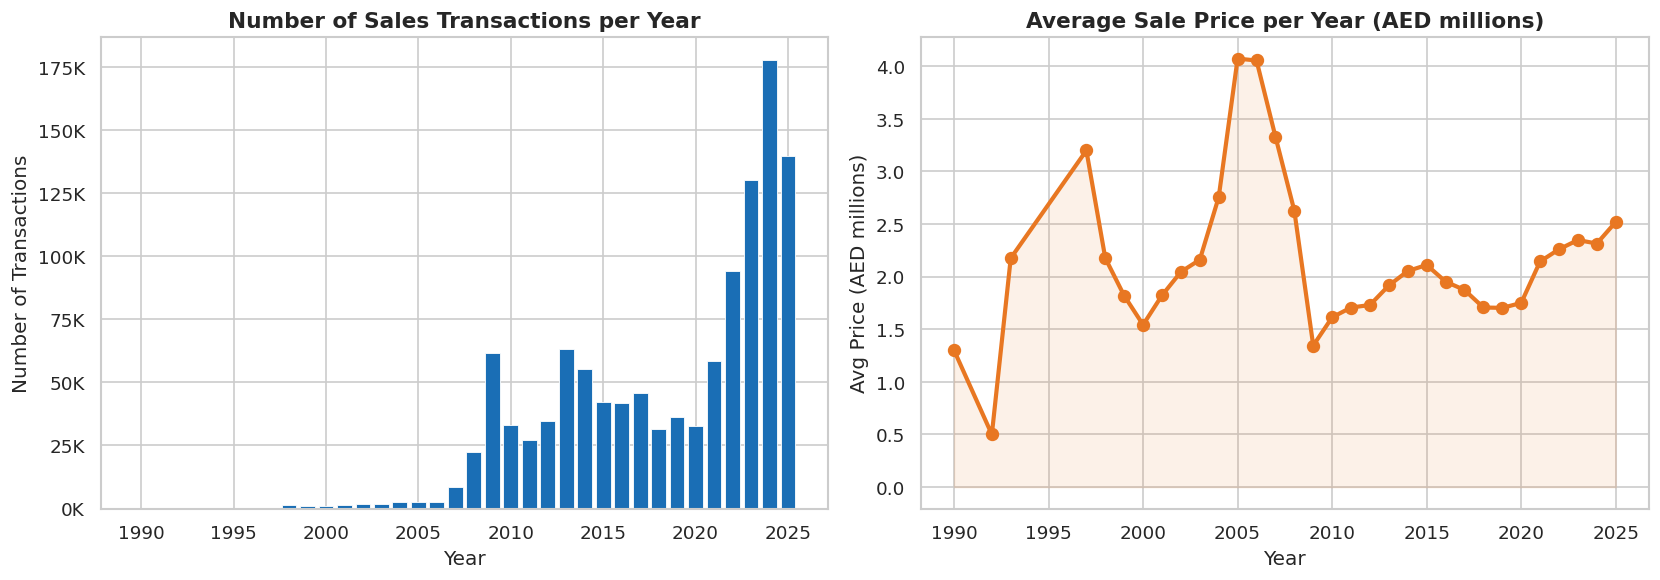

In [14]:
yearly = df.groupby('year').agg(
    transactions=('transaction_id', 'count'),
    avg_price=('actual_worth', 'mean'),
    total_value=('actual_worth', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction volume
bars = axes[0].bar(yearly['year'], yearly['transactions'], color='#1a6eb5', edgecolor='white', linewidth=0.5)
axes[0].set_title('Number of Sales Transactions per Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Transactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Average price trend
axes[1].plot(yearly['year'], yearly['avg_price'] / 1e6, marker='o', color='#e87722', linewidth=2.5, markersize=7)
axes[1].set_title('Average Sale Price per Year (AED millions)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg Price (AED millions)')
axes[1].fill_between(yearly['year'], yearly['avg_price'] / 1e6, alpha=0.1, color='#e87722')

plt.tight_layout()
plt.savefig('yearly_trends.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Property Type Analysis

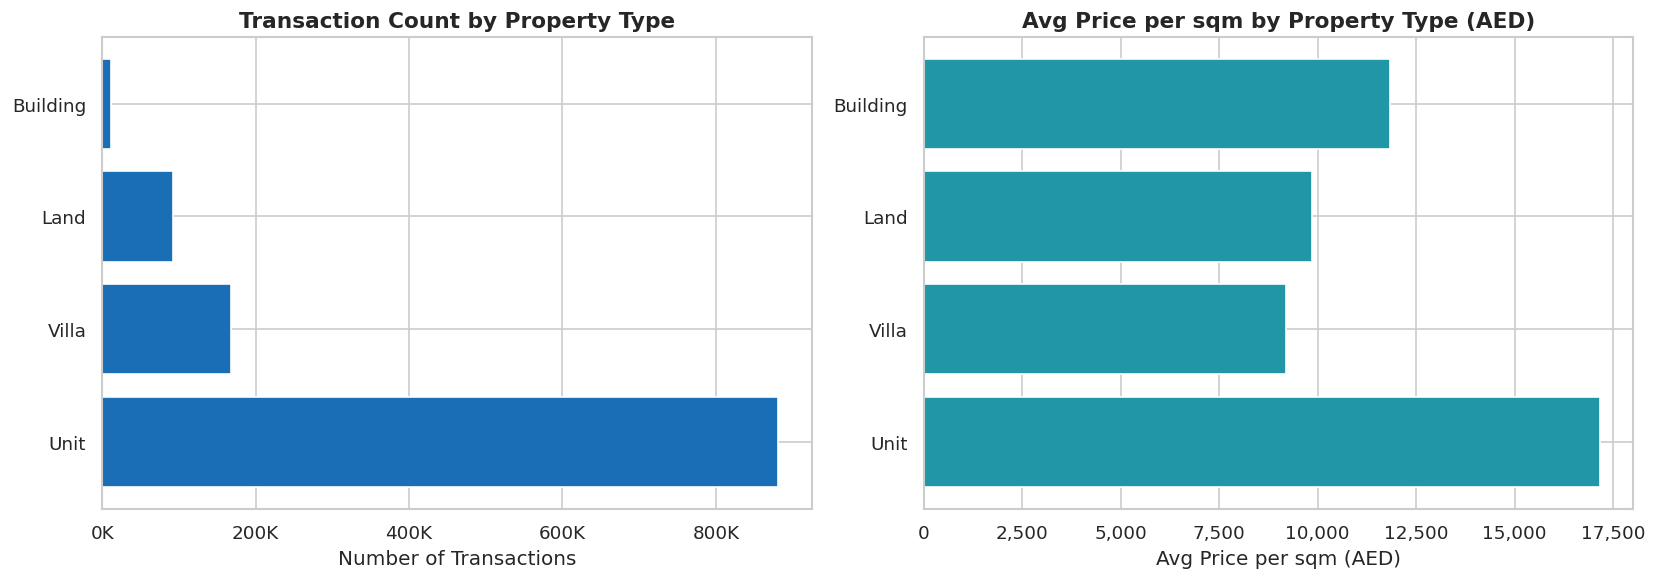

                   count     avg_price  avg_price_sqm
property_type_en                                     
Unit              881225  1.558139e+06   17153.731455
Villa             168348  3.190918e+06    9186.602696
Land               91895  4.926626e+06    9865.155954
Building           11760  7.080801e+06   11842.255101


In [15]:
prop_stats = df.groupby('property_type_en').agg(
    count=('transaction_id', 'count'),
    avg_price=('actual_worth', 'mean'),
    avg_price_sqm=('price_per_sqm', 'mean')
).sort_values('count', ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction count by type
axes[0].barh(prop_stats.index, prop_stats['count'], color='#1a6eb5')
axes[0].set_title('Transaction Count by Property Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Transactions')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Avg price per sqm by type
axes[1].barh(prop_stats.index, prop_stats['avg_price_sqm'], color='#2196a6')
axes[1].set_title('Avg Price per sqm by Property Type (AED)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Price per sqm (AED)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('property_types.png', bbox_inches='tight', dpi=150)
plt.show()

print(prop_stats.to_string())

## 6. Top 15 Areas by Average Price per sqm

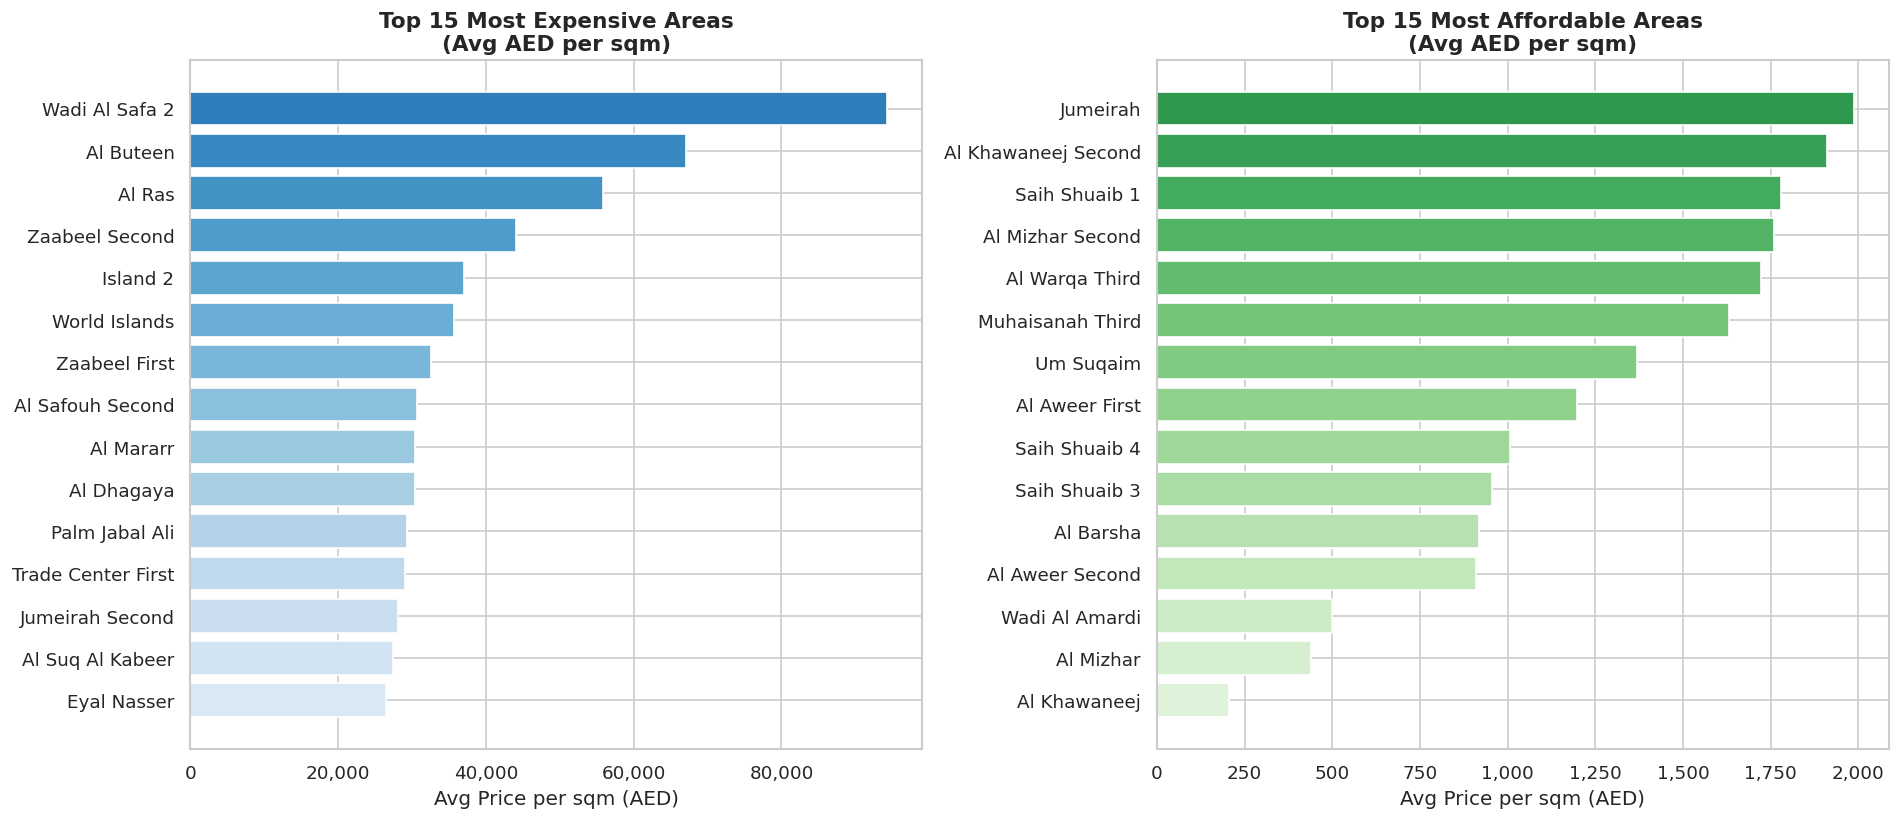

In [16]:
area_stats = df.groupby('area_name_en').agg(
    count=('transaction_id', 'count'),
    avg_price=('actual_worth', 'mean'),
    median_price=('actual_worth', 'median'),
    avg_price_sqm=('price_per_sqm', 'mean')
).reset_index()

# Only include areas with enough data (min 50 transactions)
area_stats = area_stats[area_stats['count'] >= 50].sort_values('avg_price_sqm', ascending=False)

top15 = area_stats.head(15)
bot15 = area_stats.tail(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Most expensive
colors_top = plt.cm.Blues_r(np.linspace(0.3, 0.85, len(top15)))
axes[0].barh(top15['area_name_en'], top15['avg_price_sqm'], color=colors_top)
axes[0].set_title('Top 15 Most Expensive Areas\n(Avg AED per sqm)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Avg Price per sqm (AED)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].invert_yaxis()

# Most affordable
colors_bot = plt.cm.Greens_r(np.linspace(0.3, 0.85, len(bot15)))
axes[1].barh(bot15['area_name_en'], bot15['avg_price_sqm'], color=colors_bot)
axes[1].set_title('Top 15 Most Affordable Areas\n(Avg AED per sqm)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Price per sqm (AED)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('area_prices.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Off-Plan vs Ready Market

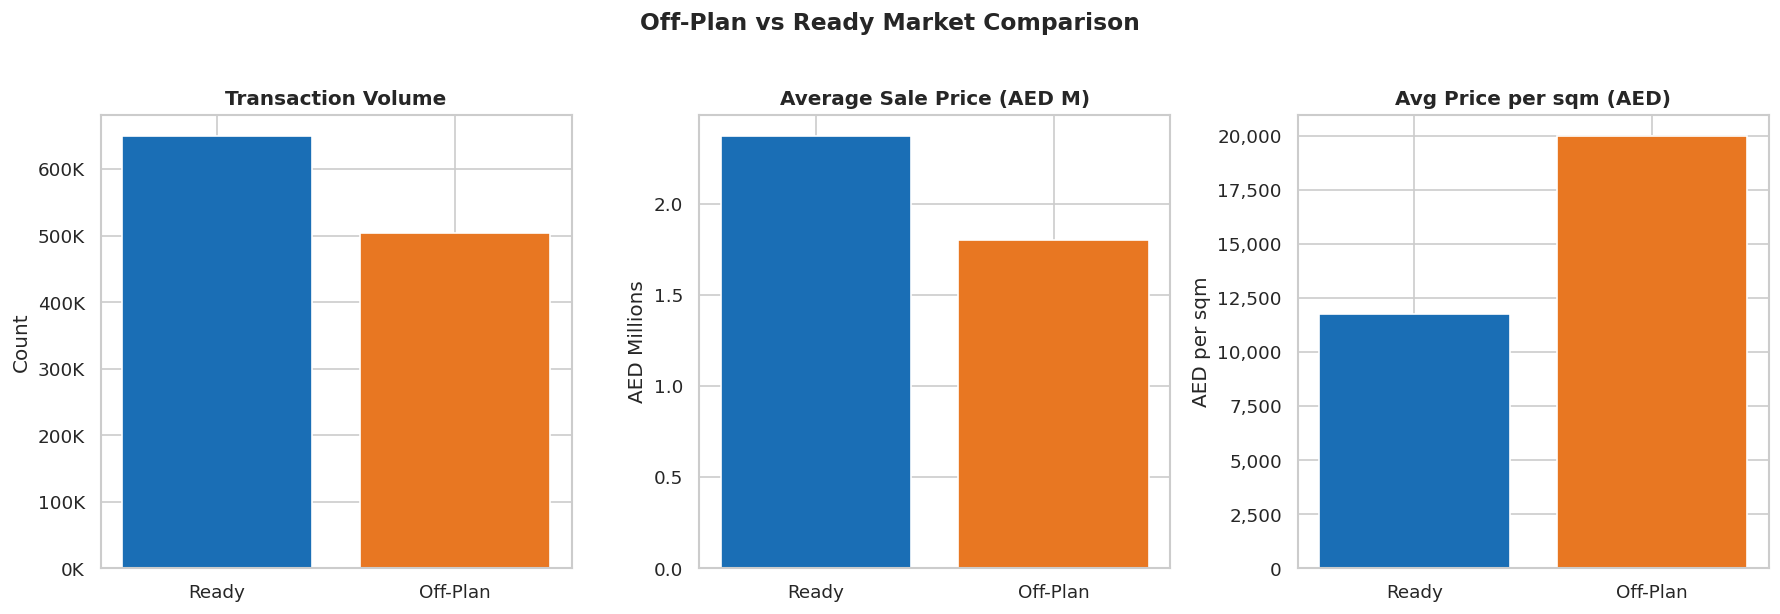

   label  count    avg_price  avg_price_sqm
   Ready 649153 2.370067e+06   11764.189188
Off-Plan 504075 1.800768e+06   19980.970916


In [17]:
offplan_stats = df.groupby('is_offplan').agg(
    count=('transaction_id', 'count'),
    avg_price=('actual_worth', 'mean'),
    avg_price_sqm=('price_per_sqm', 'mean')
).reset_index()
offplan_stats['label'] = offplan_stats['is_offplan'].map({0: 'Ready', 1: 'Off-Plan'})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#1a6eb5', '#e87722']

# Volume
axes[0].bar(offplan_stats['label'], offplan_stats['count'], color=colors)
axes[0].set_title('Transaction Volume', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Average price
axes[1].bar(offplan_stats['label'], offplan_stats['avg_price'] / 1e6, color=colors)
axes[1].set_title('Average Sale Price (AED M)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('AED Millions')

# Price per sqm
axes[2].bar(offplan_stats['label'], offplan_stats['avg_price_sqm'], color=colors)
axes[2].set_title('Avg Price per sqm (AED)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('AED per sqm')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Off-Plan vs Ready Market Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('offplan_vs_ready.png', bbox_inches='tight', dpi=150)
plt.show()

print(offplan_stats[['label', 'count', 'avg_price', 'avg_price_sqm']].to_string(index=False))

## 8. Rooms Analysis

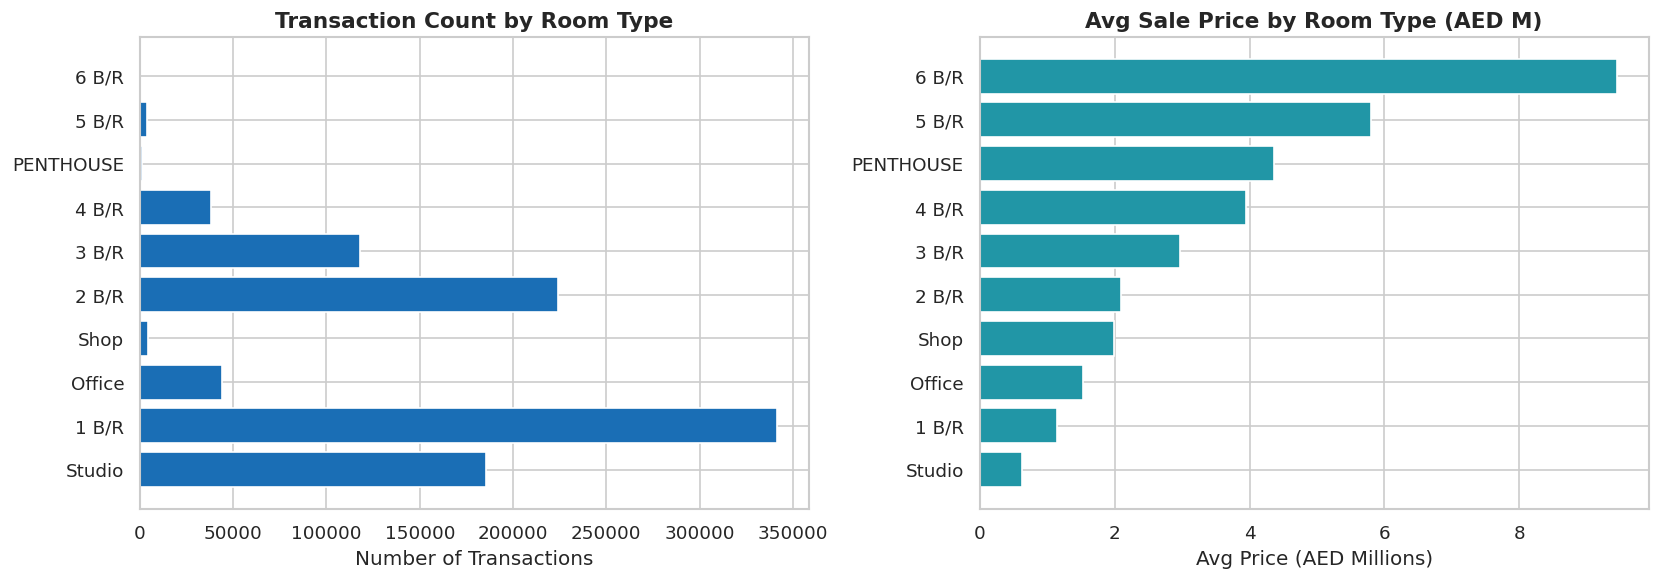

In [18]:
# Clean rooms column
rooms_df = df[df['rooms_en'].notna()].copy()
room_stats = rooms_df.groupby('rooms_en').agg(
    count=('transaction_id', 'count'),
    avg_price=('actual_worth', 'mean')
).reset_index().sort_values('avg_price', ascending=False)

# Keep top 10 most common room types
top_rooms = room_stats[room_stats['count'] > 100].head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_rooms['rooms_en'], top_rooms['count'], color='#1a6eb5')
axes[0].set_title('Transaction Count by Room Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Transactions')
axes[0].invert_yaxis()

axes[1].barh(top_rooms['rooms_en'], top_rooms['avg_price'] / 1e6, color='#2196a6')
axes[1].set_title('Avg Sale Price by Room Type (AED M)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Price (AED Millions)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('rooms_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. Correlation Heatmap

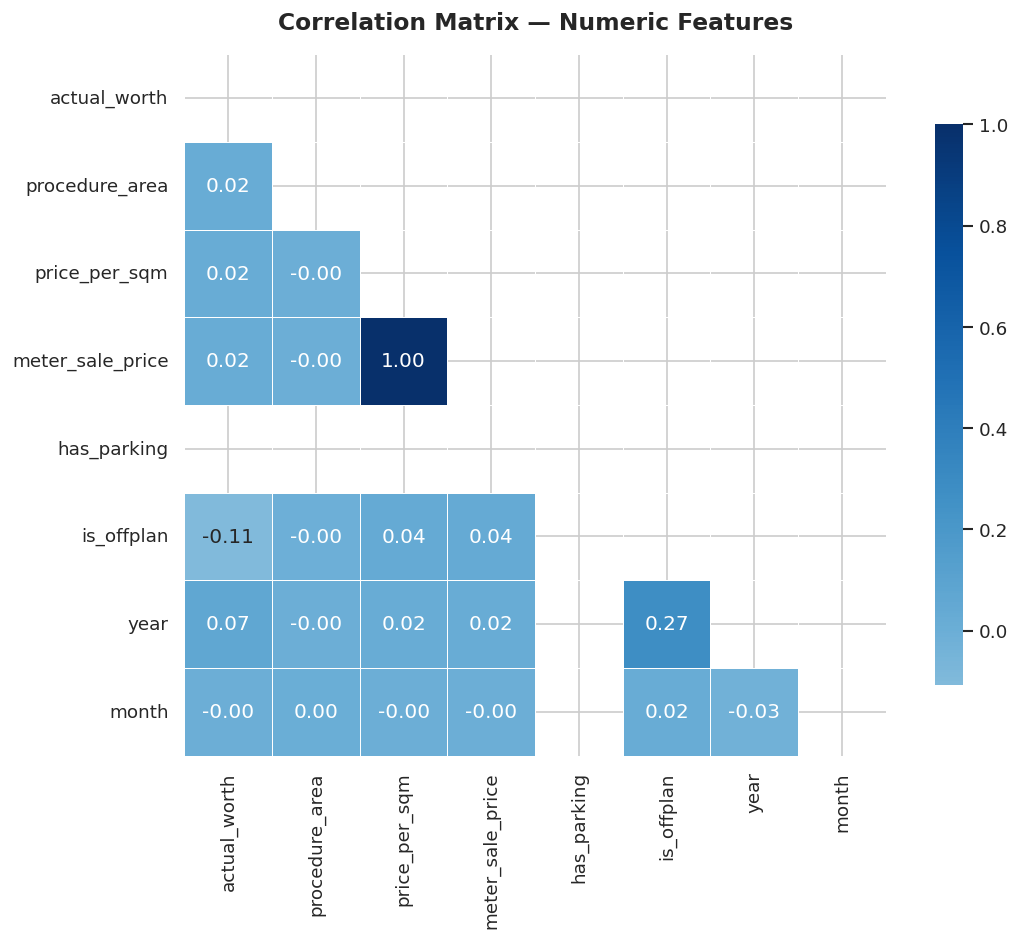

In [19]:
numeric_cols = ['actual_worth', 'procedure_area', 'price_per_sqm',
                'meter_sale_price', 'has_parking', 'is_offplan', 'year', 'month']

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

## 10. Price vs Area Scatter

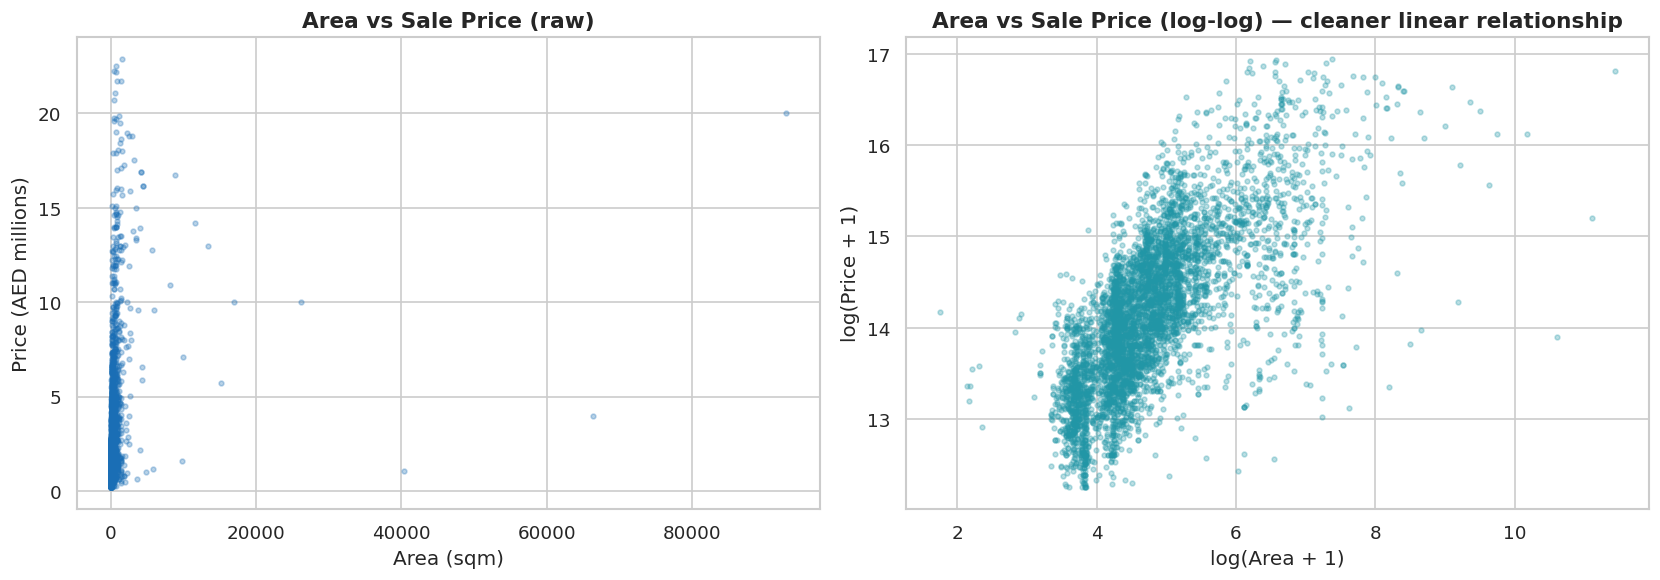

In [20]:
# Sample for plotting (scatter is slow with 1M+ points)
sample = df.sample(min(5000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw
axes[0].scatter(sample['procedure_area'], sample['actual_worth'] / 1e6,
                alpha=0.3, s=8, color='#1a6eb5')
axes[0].set_title('Area vs Sale Price (raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Area (sqm)')
axes[0].set_ylabel('Price (AED millions)')

# Log-log
axes[1].scatter(np.log1p(sample['procedure_area']), np.log1p(sample['actual_worth']),
                alpha=0.3, s=8, color='#2196a6')
axes[1].set_title('Area vs Sale Price (log-log) — cleaner linear relationship', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Area + 1)')
axes[1].set_ylabel('log(Price + 1)')

plt.tight_layout()
plt.savefig('price_vs_area.png', bbox_inches='tight', dpi=150)
plt.show()

## 11. EDA Summary — Key Findings

In [21]:
print('=' * 60)
print('EDA KEY FINDINGS')
print('=' * 60)

print(f'\n Total Sales Transactions Analysed: {len(df):,}')

print(f'\n Price Range (after outlier removal):')
print(f'   Min:    AED {df["actual_worth"].min():>15,.0f}')
print(f'   Median: AED {df["actual_worth"].median():>15,.0f}')
print(f'   Mean:   AED {df["actual_worth"].mean():>15,.0f}')
print(f'   Max:    AED {df["actual_worth"].max():>15,.0f}')

print(f'\n Most Expensive Area (avg/sqm):')
top_area = area_stats.iloc[0]
print(f'   {top_area["area_name_en"]} — AED {top_area["avg_price_sqm"]:,.0f}/sqm')

print(f'\n Most Affordable Area (avg/sqm):')
bot_area = area_stats.iloc[-1]
print(f'   {bot_area["area_name_en"]} — AED {bot_area["avg_price_sqm"]:,.0f}/sqm')

offplan_pct = df['is_offplan'].mean() * 100
print(f'\n Off-Plan Share: {offplan_pct:.1f}% of all sales')

parking_pct = df['has_parking'].mean() * 100
print(f'\n Properties with Parking: {parking_pct:.1f}%')

print(f'\n Peak Transaction Year: {df.groupby("year")["transaction_id"].count().idxmax()}')

print('\n' + '=' * 60)
print('Ready for Notebook 02: Feature Engineering & Modelling')
print('=' * 60)

EDA KEY FINDINGS

 Total Sales Transactions Analysed: 1,153,228

 Price Range (after outlier removal):
   Min:    AED         210,000
   Median: AED       1,347,141
   Mean:   AED       2,121,227
   Max:    AED      23,599,000

 Most Expensive Area (avg/sqm):
   Wadi Al Safa 2 — AED 94,328/sqm

 Most Affordable Area (avg/sqm):
   Al Khawaneej — AED 204/sqm

 Off-Plan Share: 43.7% of all sales

 Properties with Parking: nan%

 Peak Transaction Year: 2024

Ready for Notebook 02: Feature Engineering & Modelling


## 12. Save Cleaned Data


In [22]:
# Save cleaned dataframe for use in next notebook
df.to_csv('transactions_cleaned.csv', index=False)
print(f'Saved transactions_cleaned.csv — {df.shape[0]:,} rows, {df.shape[1]} columns')
print('Load this in Notebook 02 with: df = pd.read_csv("transactions_cleaned.csv")')

Saved transactions_cleaned.csv — 1,153,228 rows, 51 columns
Load this in Notebook 02 with: df = pd.read_csv("transactions_cleaned.csv")
